# Step 5 -- 2D Linear Convection

We now move from 1D to 2D. The governing PDE is the 2D linear advection equation:

$$
\frac{\partial u}{\partial t}
+ c_x \frac{\partial u}{\partial x}
+ c_y \frac{\partial u}{\partial y} = 0
$$

where $(c_x, c_y)$ is a constant velocity vector.

**What you will learn:**

1. How somax represents 2D fields on a regular grid
2. The Arakawa C-grid staggering convention
3. How to run a 2D simulation and visualize the result
4. How to differentiate through the 2D solver

## Background: Arakawa C-grid

On a **collocated** grid every variable lives at the cell centre. The **Arakawa C-grid** staggers velocity components: $u$ sits on the east/west cell faces, $v$ on the north/south faces, and scalars (pressure, tracers) at cell centres. This arrangement naturally satisfies discrete continuity and avoids the 2dx pressure mode.

For pure scalar advection (this step) we place the scalar $u$ at cell centres with shape `(Ny, Nx)`.

## Grid layout and boundary conditions

In 2D, somax uses the **Arakawa C-grid** where different variables live at different positions within each cell:

```
       V_{j+1/2}
    ┌─────●─────┐
    │           │
 U  ●     T     ●  U
i-1/2   (i,j)    i+1/2
    │           │
    └─────●─────┘
       V_{j-1/2}
```

- **T-points** (cell centres): scalars ($u$, $p$, $\omega$)
- **U-points** (east/west faces): x-fluxes
- **V-points** (north/south faces): y-fluxes
- **X-points** (corners): vorticity (in some formulations)

The full array has shape `(Ny, Nx)` with a **1-cell ghost ring** on all sides:

```
 ┌───────────────────────────────────┐
 │  ghost  ghost  ghost  ghost  ghost│  ← row 0
 │  ghost  T(1,1) T(1,2) ···   ghost│  ← row 1
 │  ghost  T(2,1) T(2,2) ···   ghost│
 │   ⋮      ⋮      ⋮           ⋮    │
 │  ghost  T(n,1) T(n,2) ···   ghost│  ← row Ny-2
 │  ghost  ghost  ghost  ghost  ghost│  ← row Ny-1
 └───────────────────────────────────┘
        col 0  col 1  ···  col Nx-1
```

Interior cells are `[1:-1, 1:-1]`. Ghost cells are filled by boundary conditions before each RHS evaluation.

**Periodic BCs** (`enforce_periodic`) copy the last interior row/column to the opposite ghost row/column:

```
 field[0, :]  = field[-2, :]   (south ghost ← north interior)
 field[-1, :] = field[1, :]    (north ghost ← south interior)
 field[:, 0]  = field[:, -2]   (west ghost ← east interior)
 field[:, -1] = field[:, 1]    (east ghost ← west interior)
```

In [1]:
from __future__ import annotations

import diffrax as dfx
import equinox as eqx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

from somax.models import LinearConvection2D, LinearConvection2DState

## 1. Create the model and grid

In [2]:
model = LinearConvection2D.create(
    nx=64,
    ny=64,
    Lx=2.0,
    Ly=2.0,
    cx=1.0,
    cy=0.5,
)
print(model)
print(f"Grid: Nx={model.grid.Nx}, Ny={model.grid.Ny}")
print(f"Spacing: dx={model.grid.dx:.4f}, dy={model.grid.dy:.4f}")

LinearConvection2D(
  params=LinearConvection2DParams(cx=weak_f32[], cy=weak_f32[]),
  grid=ArakawaCGrid2D(Nx=66, Ny=66, Lx=2.0, Ly=2.0, dx=0.03125, dy=0.03125),
  diff=Difference2D(
    grid=ArakawaCGrid2D(Nx=66, Ny=66, Lx=2.0, Ly=2.0, dx=0.03125, dy=0.03125)
  ),
  interp=Interpolation2D(
    grid=ArakawaCGrid2D(Nx=66, Ny=66, Lx=2.0, Ly=2.0, dx=0.03125, dy=0.03125)
  )
)
Grid: Nx=66, Ny=66
Spacing: dx=0.0312, dy=0.0312


## 2. Initial condition

A 2D Gaussian centred at $(1.0, 1.0)$:

$$
u_0(x, y) = \exp\!\Bigl[
  -\frac{(x - 1)^2 + (y - 1)^2}{2\sigma^2}
\Bigr]
$$

In [3]:
x = jnp.arange(model.grid.Nx) * model.grid.dx
y = jnp.arange(model.grid.Ny) * model.grid.dy
X, Y = jnp.meshgrid(x, y)

sigma0 = 0.2
u0 = jnp.exp(-0.5 * (((X - 1.0) / sigma0) ** 2 + ((Y - 1.0) / sigma0) ** 2))
state0 = LinearConvection2DState(u=u0)

print(f"State shape: u={state0.u.shape}")

State shape: u=(66, 66)


## 3. Run the simulation

In [4]:
dt = 0.002
t_final = 0.5
ts = jnp.arange(0.0, t_final, dt)

sol = model.integrate(
    state0,
    t0=0.0,
    t1=t_final,
    dt=dt,
    saveat=dfx.SaveAt(ts=ts),
)

print(f"Solution shape: {sol.ys.u.shape}")

Solution shape: (250, 66, 66)


## 4. Visualize initial and final fields

We plot only the interior cells (excluding ghost cells) using `pcolormesh`.

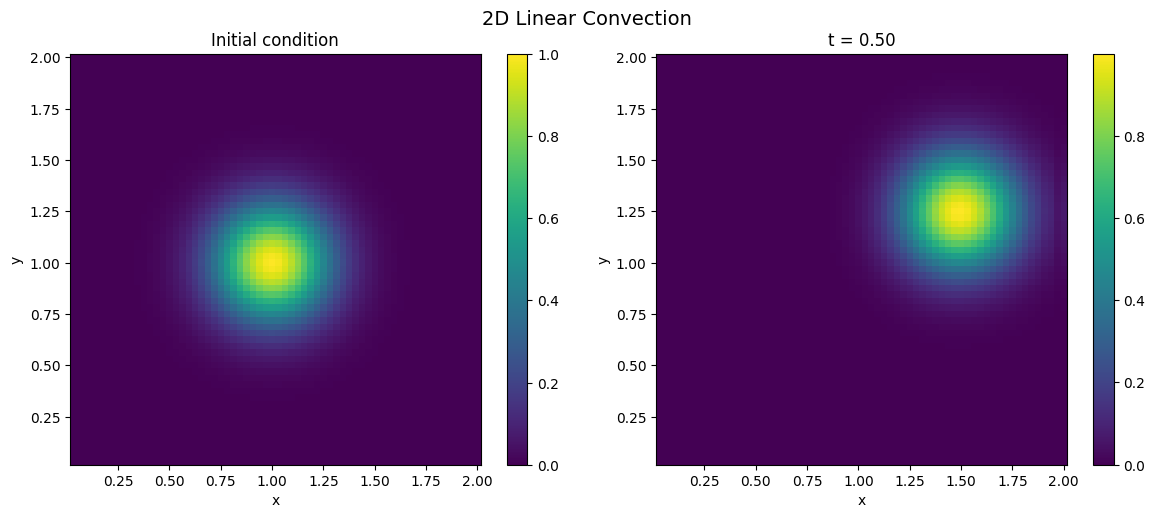

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, field, title in zip(
    axes,
    [sol.ys.u[0], sol.ys.u[-1]],
    ["Initial condition", f"t = {float(ts[-1]):.2f}"],
    strict=True,
):
    pcm = ax.pcolormesh(
        X[1:-1, 1:-1],
        Y[1:-1, 1:-1],
        field[1:-1, 1:-1],
        shading="auto",
        cmap="viridis",
    )
    plt.colorbar(pcm, ax=ax)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(title)
    ax.set_aspect("equal")

plt.suptitle("2D Linear Convection", fontsize=14)
plt.tight_layout()
plt.show()

The Gaussian translates in the $(c_x, c_y) = (1.0, 0.5)$ direction without changing shape -- exactly what the linear advection equation predicts.

## 5. Cross-section through the centre

A 1D slice along the mid-y row shows the translation more clearly.

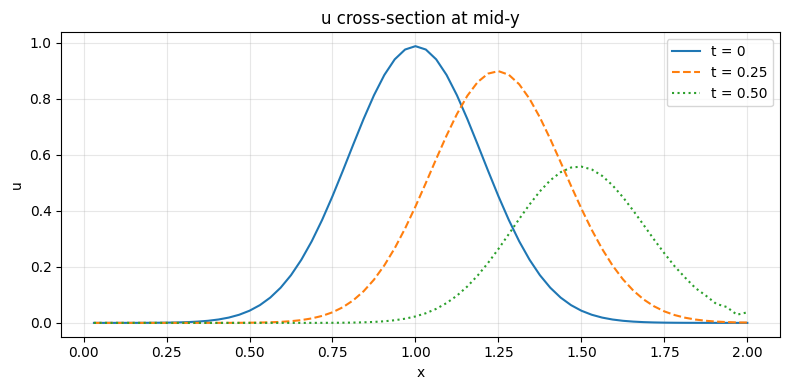

In [6]:
mid_y = model.grid.Ny // 2

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x[1:-1], sol.ys.u[0, mid_y, 1:-1], label="t = 0", lw=1.5)
ax.plot(
    x[1:-1],
    sol.ys.u[len(ts) // 2, mid_y, 1:-1],
    label=f"t = {float(ts[len(ts) // 2]):.2f}",
    lw=1.5,
    ls="--",
)
ax.plot(
    x[1:-1],
    sol.ys.u[-1, mid_y, 1:-1],
    label=f"t = {float(ts[-1]):.2f}",
    lw=1.5,
    ls=":",
)
ax.set_xlabel("x")
ax.set_ylabel("u")
ax.set_title("u cross-section at mid-y")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The pulse shifts to the right at speed $c_x = 1.0$ without changing amplitude -- the hallmark of linear advection.

## 6. Mass conservation check

Linear advection conserves total mass $\int u\,dx\,dy$. We verify this by tracking the sum over time.

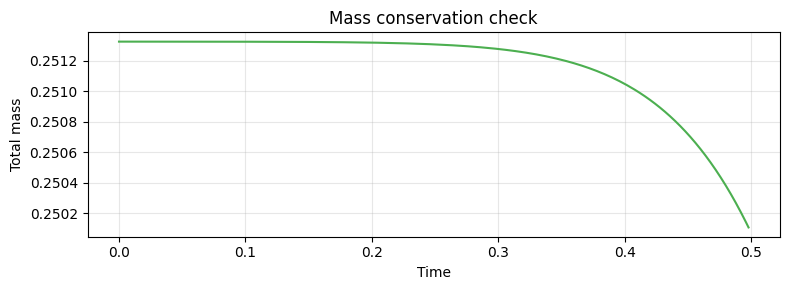

Mass: initial = 0.251327, final = 0.250106
Relative change: 4.86e-03


In [7]:
dx_val, dy_val = float(model.grid.dx), float(model.grid.dy)
mass = jnp.sum(sol.ys.u[:, 1:-1, 1:-1], axis=(1, 2)) * dx_val * dy_val

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(ts, mass, lw=1.5, color="#4CAF50")
ax.set_xlabel("Time")
ax.set_ylabel("Total mass")
ax.set_title("Mass conservation check")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Mass: initial = {float(mass[0]):.6f}, final = {float(mass[-1]):.6f}")
print(f"Relative change: {abs(float((mass[-1] - mass[0]) / mass[0])):.2e}")

## 7. Gradient through convection speeds

Because somax models are equinox modules, we can differentiate the solution with respect to the advection velocities $(c_x, c_y)$.

In [8]:
@eqx.filter_grad
def grad_convection_speeds(m):
    sol = m.integrate(state0, t0=0.0, t1=0.2, dt=0.002)
    return jnp.sum(sol.ys.u**2)


grads = grad_convection_speeds(model)

print("--- Gradient w.r.t. convection speeds ---")
print(f"  dL/d(cx) = {grads.params.cx:.6f}")
print(f"  dL/d(cy) = {grads.params.cy:.6f}")

--- Gradient w.r.t. convection speeds ---
  dL/d(cx) = 0.000003
  dL/d(cy) = 0.000025


## 8. Gradient through the initial state

We can also compute gradients with respect to the initial field -- the building block for data assimilation (4D-Var) in 2D.

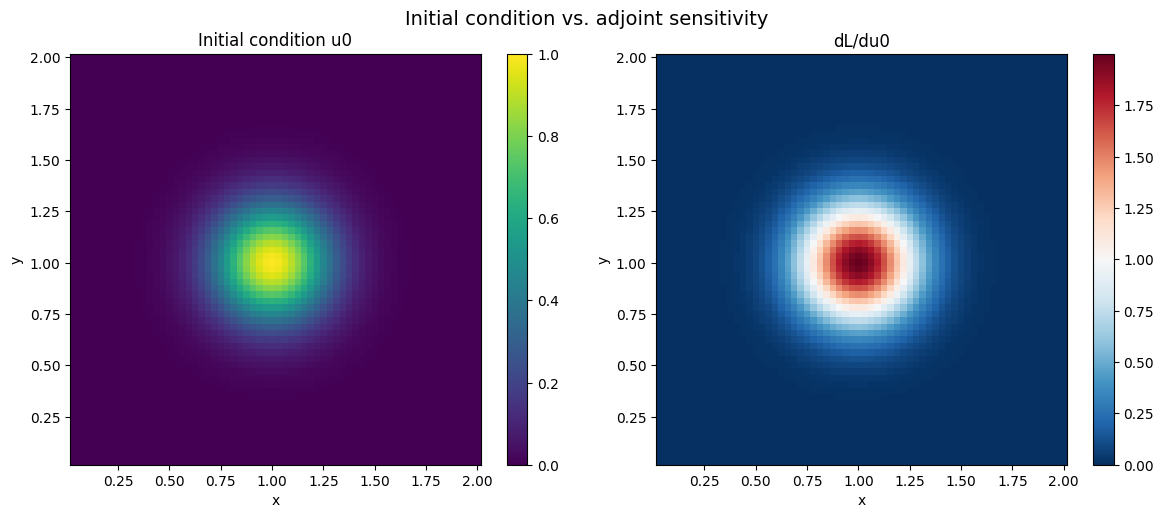

In [9]:
def loss_state(s0):
    sol = model.integrate(s0, t0=0.0, t1=0.2, dt=0.002)
    return jnp.sum(sol.ys.u**2)


grad_u0 = jax.grad(loss_state)(state0)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

pcm0 = axes[0].pcolormesh(
    X[1:-1, 1:-1],
    Y[1:-1, 1:-1],
    state0.u[1:-1, 1:-1],
    shading="auto",
    cmap="viridis",
)
plt.colorbar(pcm0, ax=axes[0])
axes[0].set_title("Initial condition u0")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].set_aspect("equal")

pcm1 = axes[1].pcolormesh(
    X[1:-1, 1:-1],
    Y[1:-1, 1:-1],
    grad_u0.u[1:-1, 1:-1],
    shading="auto",
    cmap="RdBu_r",
)
plt.colorbar(pcm1, ax=axes[1])
axes[1].set_title("dL/du0")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
axes[1].set_aspect("equal")

plt.suptitle("Initial condition vs. adjoint sensitivity", fontsize=14)
plt.tight_layout()
plt.show()

## Summary

| Concept | API |
|---------|-----|
| Create 2D model | `LinearConvection2D.create(nx=64, ...)` |
| Grid coordinates | `jnp.arange(grid.Nx) * grid.dx` |
| Initial state | `LinearConvection2DState(u=u0)` with `u0.shape == (Ny, Nx)` |
| Grad w.r.t. params | `eqx.filter_grad(loss)(model)` |
| Grad w.r.t. state | `jax.grad(loss)(state0)` |

**Next:** Step 6 extends to nonlinear convection in 2D, where the velocity is no longer constant but depends on the solution itself.